# NFL Combine - RB vs WR Athleticism Project

by Minh Truong and Mallie Lange

Project 1

Principal Component Analysis (PCA) is fundamentally a dimensionality reduction algorithm that transforms high-dimensional data into a lower-dimensional space while preserving the most important variance in the dataset. By identifying the principal components—the directions of maximum variance—PCA enables us to reduce computational complexity and mitigate the curse of dimensionality.

Beyond dimensionality reduction, PCA serves multiple practical purposes in data science and machine learning. As a visualization tool, it allows us to project complex, high-dimensional datasets into two or three dimensions, making patterns and clusters visible to the human eye. For noise filtering, PCA can separate the signal from noise by retaining only the components with significant variance while discarding those that primarily capture random fluctuations.

In feature extraction and engineering, PCA creates new features that are linear combinations of the original variables, often revealing underlying structure in the data that wasn’t immediately apparent. PCA finds applications in data compression, anomaly detection, and as a preprocessing step to improve the performance and training speed of machine learning algorithms.

Find a dataset and perform PCA to highlight its key concepts and provide outputs accordingly.

<u>**Grading Rubric/Criteria:**</u>

1. [x] Dataset used – provide source information or dataset – 10 points.
2. [x] List Libraries used – 20 points.
3. [x] Perform necessary tasks associated with PCA - Scaling, dimensionality reduction, etc., as needed – 75 points.
4. [x] Provide necessary visualizations/graphs – 75 points.
5. [x] Provide comments as needed to explain your analysis – 20 points.

<u>**What you need to submit:**/u>

1. Your code as a Word/PDF, complete with graphs.
2. A PPT with 2- 4 slides max. including the introduction slide.
    - Slides to have dataset information – source
    - Explain the concept of PCA and its application to your dataset
    - Visualization/graphs as needed
    - Speaker Notes: Add detailed explanations in the notes pane
3. No recording is needed.

# 1. Import packages

### List Libraries used

In [154]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 2. EDA

### Dataset used – provide source information or dataset

### Step 1: Read the data

In [155]:
# Step 2: Load Data
NFL_combine = pd.read_csv('2025 NFL Combine Dataset.csv')

### Step 2: Narrow the data

I want to focus only on the running back and wide receiver positions instead of examining all the 7 positions.

In [156]:
# Filter the dataset for only the skill positions of RB and WR
skill_pos = NFL_combine[NFL_combine['Position'].isin(['RB', 'WR'])].copy()

# Display counts of players on skill positions
print(f"Skill players: RB={len(skill_pos[skill_pos.Position=='RB'])}, WR={len(skill_pos[skill_pos.Position=='WR'])}")

Skill players: RB=31, WR=49


### Step 3: Understand the data

In [157]:
# Display the first few rows of the dataset
skill_pos.head()

,Name,Position,School,Height,Weight,Hand Size,Arm Length,Wingspan,40 Yard Dash,Bench Press,Vertical Jump,Broad Jump,3-Cone Drill,20 Yard Shuttle,Athleticism Score,Height (Numeric),Hand (Numeric),Arm (Numeric),Wingspan (Numeric)
5,Josh Kelly,WR,Texas Tech,6-0 5/8,186,10 1/2,30 7/8,NaN,4.70,NaN,33,10 1/12,7.02,NaN,55,6.052083333,10.5,NaN,0
12,Theo Wease Jr.,WR,Missouri,6-3,200,9 5/8,32 1/8,NaN,4.56,NaN,31,9 3/4,NaN,NaN,59,6.25,9.625,NaN,0
15,Ricky White III,WR,UNLV,6-1 1/8,184,9 1/4,31 3/4,NaN,4.61,NaN,36,10 1/4,NaN,NaN,61,6.09375,9.25,NaN,0
17,Konata Mumpfield,WR,Pittsburgh,5-11 3/8,186,8 1/2,29 3/8,NaN,4.59,NaN,36,10 1/3,NaN,NaN,62,5.947916667,8.5,NaN,0
25,Kaleb Johnson,RB,Iowa,6-1,224,9 5/8,33,78 1/2,4.57,NaN,NaN,NaN,NaN,NaN,64,6,9.625,33,78.5


In [158]:
# Display the data types of the array
skill_pos.dtypes

Name                   object
Position               object
School                 object
Height                 object
Weight                  int64
Hand Size              object
Arm Length             object
Wingspan               object
40 Yard Dash           object
Bench Press           float64
Vertical Jump          object
Broad Jump             object
3-Cone Drill          float64
20 Yard Shuttle       float64
Athleticism Score       int64
Height (Numeric)       object
Hand (Numeric)         object
Arm (Numeric)          object
Wingspan (Numeric)     object
dtype: object

In [159]:
# Check which features are missing values to help with feature selection
skill_pos.isnull().sum()

Name                   0
Position               0
School                 0
Height                 0
Weight                 0
Hand Size              0
Arm Length             0
Wingspan              49
40 Yard Dash          10
Bench Press           64
Vertical Jump         22
Broad Jump            24
3-Cone Drill          68
20 Yard Shuttle       64
Athleticism Score      0
Height (Numeric)       0
Hand (Numeric)         1
Arm (Numeric)         49
Wingspan (Numeric)     0
dtype: int64

### Step 4: Choose feautures

In [160]:
# These features were chosen because these are the most valuable when analyzing an RB or WR from an NFL scouting perspective
# In addition, we keep almost all 80 players, giving PCA more to work with, and 0 to 1% missing data
features = ['Weight', 'Height (Numeric)', 'Hand (Numeric)', '40 Yard Dash']

# Converts each column in the features list to a numeric data type and replaces empty strings with NaN
for col in features:
    skill_pos[col] = pd.to_numeric(skill_pos[col], errors='coerce')

### Step 5: Descriptive Statistics

In [161]:
# Displays descriptive statistics of both RB and WR combined
skill_pos.describe()

,Weight,40 Yard Dash,Bench Press,3-Cone Drill,20 Yard Shuttle,Athleticism Score,Height (Numeric),Hand (Numeric)
count,80.000000,63.000000,16.000000,12.000000,16.000000,80.000000,80.000000,79.000000
mean,202.087500,4.470635,17.250000,6.859167,4.230625,75.575000,6.006901,9.272152
std,14.708298,0.089531,3.316625,0.123027,0.109390,9.658439,0.195967,0.502302
min,154.000000,4.290000,11.000000,6.650000,4.050000,54.000000,5.666667,7.750000
25%,193.750000,4.405000,15.750000,6.807500,4.165000,68.000000,5.841146,9.000000
50%,204.000000,4.460000,17.000000,6.830000,4.225000,75.000000,6.000000,9.250000
75%,212.250000,4.545000,19.000000,6.917500,4.307500,82.250000,6.148437,9.500000
max,234.000000,4.700000,23.000000,7.100000,4.410000,96.000000,6.479167,10.500000


In [162]:
# Separate and display descriptive statistics by skill position for more insight
print(skill_pos.groupby('Position')[features].mean().round(2))
print(skill_pos.groupby('Position')[features].std().round(2))

          Weight  Height (Numeric)  Hand (Numeric)  40 Yard Dash
Position                                                        
RB        210.61              5.88            9.20          4.48
WR        196.69              6.09            9.31          4.46
          Weight  Height (Numeric)  Hand (Numeric)  40 Yard Dash
Position                                                        
RB         10.77              0.14            0.51          0.08
WR         14.38              0.18            0.50          0.09


### Step 6: Check for missing values

In [163]:
# Resolve any missing values before proceeding because PCAs cannot handle NaN
print("Missing Values:")
missing = skill_pos[features].isnull().sum()
pct = (missing / len(skill_pos) * 100).round(1)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': pct}))

Missing Values:
                  Missing Count  Missing %
Weight                        0        0.0
Height (Numeric)              0        0.0
Hand (Numeric)                1        1.2
40 Yard Dash                 17       21.2


In [164]:
# Drop rows with missing values/incomplete rows
skill_pos_clean = skill_pos[['Position'] + features].dropna()
print(f"\nRetained: {len(skill_pos_clean)} players after cleanup "
      f"(RB={sum(skill_pos_clean.Position=='RB')}, WR={sum(skill_pos_clean.Position=='WR')})")

X = skill_pos_clean[features].values
positions = skill_pos_clean['Position'].values


Retained: 63 players after cleanup (RB=24, WR=39)


In [165]:
# Separate and display descriptive statistics by skill position for more insight
print(skill_pos_clean.groupby('Position')[features].mean().round(2))
print(skill_pos_clean.groupby('Position')[features].std().round(2))

          Weight  Height (Numeric)  Hand (Numeric)  40 Yard Dash
Position                                                        
RB        208.58              5.87            9.13          4.48
WR        196.08              6.09            9.29          4.46
          Weight  Height (Numeric)  Hand (Numeric)  40 Yard Dash
Position                                                        
RB          9.40              0.12            0.49          0.08
WR         14.43              0.19            0.53          0.09


### Step 7: Plot the respective graphs

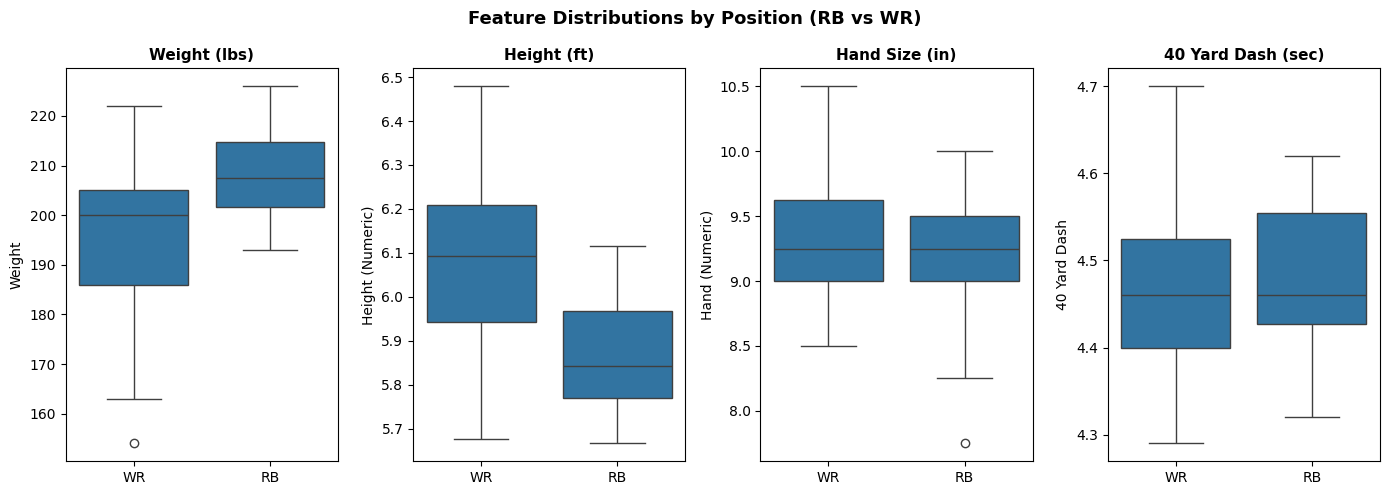

In [166]:
# EDA Figure 1: Boxplots
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle('Feature Distributions by Position (RB vs WR)', fontsize=13, fontweight='bold')

for i, feat in enumerate(features):
    sns.boxplot(data=skill_pos_clean, x='Position', y=feat, ax=axes[i])
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[0].set_title('Weight (lbs)', fontsize=11, fontweight='bold')
    axes[1].set_title('Height (ft)', fontsize=11, fontweight='bold')
    axes[2].set_title('Hand Size (in)', fontsize=11, fontweight='bold')
    axes[3].set_title('40 Yard Dash (sec)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_fig1_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis:**

- RBs are heavier (mean of 208.58 lbs vs. 196.08 lbs) and shorter (5.87 ft vs. 6.09 ft) than WRs. This makes sense because historically and generally, RBs require a lower center of gravity and contact tolerance. 
- WRs have slightly larger hands on average (9.31 in vs 9.20 in). This is consistent with their role because larger hands help them catch the ball better.
- Both positions ran nearly identical 40 Yard Dash times (4.48 vs 4.46 sec). In conclusion, speed is a universal baseline at these skill positions regardless of size.

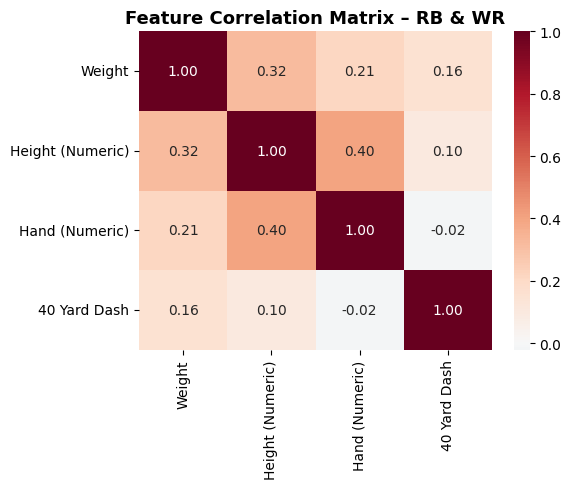

In [167]:
# EDA Figure 2: Correlation Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(skill_pos_clean[features].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix – RB & WR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_fig2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis:**

- Feature correlations are from 0.10–0.40. This is moderate and means that each 4 scouting measurements are independent of one another and contributes something to the analysis.
- The strongest correlation is 0.40 between Height and Hand Size. This makes sense because taller players tend to have longer fingers.
- The near-zero correlation of -0.02 between Hand Size and 40 Yard Dash male sense and confirms speed and hand size are completely independent of one another.

# 3. PCA

### Step 1: Feature Scaling

In [168]:
# Weight (lbs) and 40 Yard Dash (sec) are on very different scales, so StandardScaler gives each feature mean=0, std=1 so that none dominates PCA

# Creates an instance of the StandardScaler and name it scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [169]:
# Full PCA — Explained Variance

# Fit PCA using all 4 components so we can see the full variance picture
pca_full = PCA()
pca_full.fit(X_scaled)

# explained_variance_ratio_ gives the % of variance each PC captures
ev = pca_full.explained_variance_ratio_

# Cumulative sum adds them up progressively
cumev = np.cumsum(ev)

# Find the minimum number of components needed to hit the 90% and 95% thresholds
# argmax returns the index of the first True value, +1 converts from 0-based index to component number
n90 = np.argmax(cumev >= 0.90) + 1
n95 = np.argmax(cumev >= 0.95) + 1

# Print a summary of how much variance each PC captures and how many components we need to retain most of the information
print(f"\nPC1: {ev[0]*100:.1f}% | PC2: {ev[1]*100:.1f}% | Combined: {(ev[0]+ev[1])*100:.1f}%")
print(f"Components for 90%: {n90} | For 95%: {n95}")


PC1: 41.4% | PC2: 26.0% | Combined: 67.4%
Components for 90%: 4 | For 95%: 4


### Step 2: Provide necessary visualizations/graphs

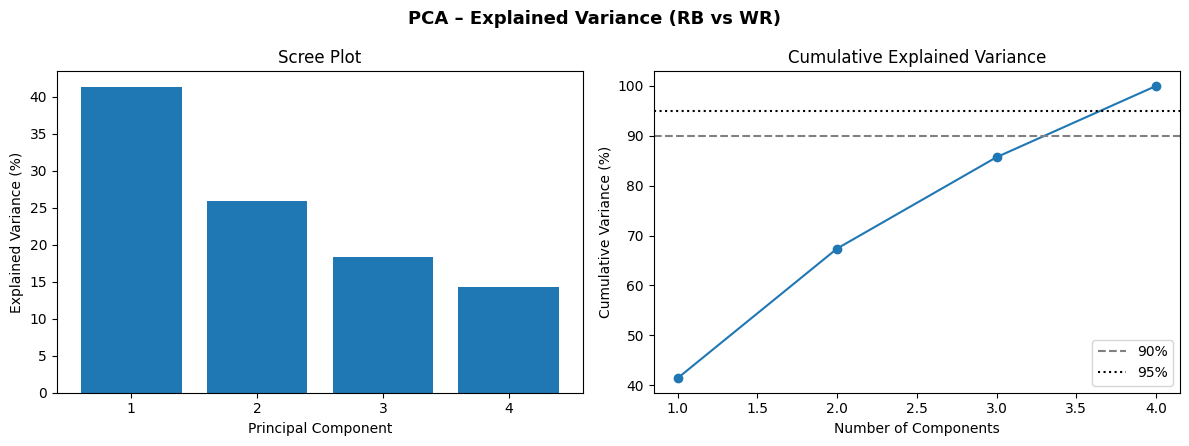

In [170]:
# PCA Figure 1: Scree Plot + Cumulative Variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('PCA – Explained Variance (RB vs WR)', fontsize=13, fontweight='bold')
comps = np.arange(1, len(ev) + 1)

axes[0].bar(comps, ev * 100)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(comps)

axes[1].plot(comps, cumev * 100, marker='o')
axes[1].axhline(90, color='gray', linestyle='--', label='90%')
axes[1].axhline(95, color='black', linestyle=':', label='95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.savefig('rbwr_fig1_scree.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis:**

**Scree Plot & Cumulative Variance**
- PC1 captures 41.4% and PC2 captures 26.0% of the variance. These 2 dimemcions capture 67.4% of the total information.
- All 4 components are needed to capture 90% variance, with PC3 (18.3%) and PC4 (14.3%) contributing much smaller amounts than PC1 and PC2.
- No single feature dominates and each scouting measurement contributes something unique as indicated by the gradual scree slope.

### Step 3: Reduce to 2 Components

#### Dimensionality reduction
We reduce to 2 dimensions because PC1 and PC2 already capture the dominant structure in our data. Everything after that is diminishing returns and not that significant to our purpose.

In [171]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)
print(f"2D variance retained: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")

2D variance retained: 67.4%


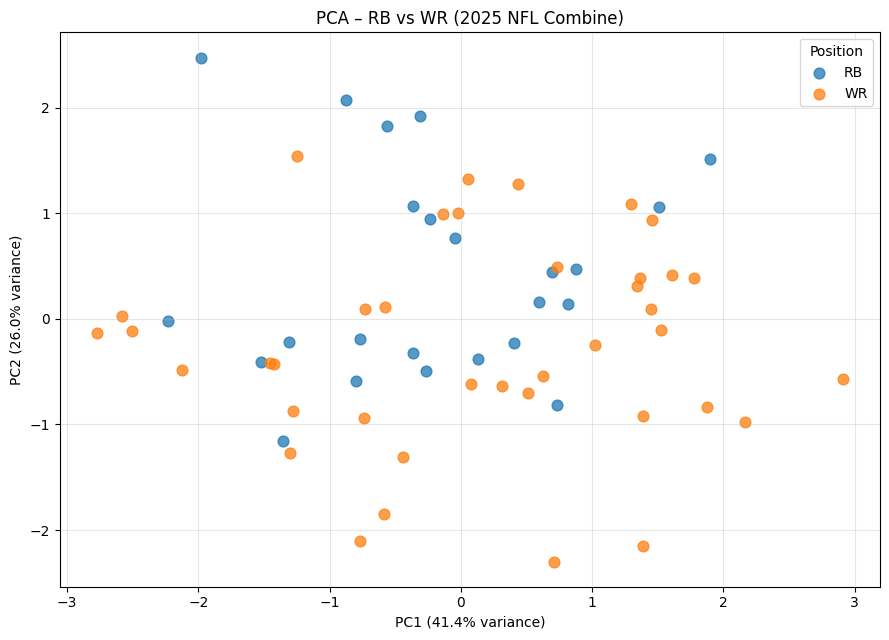

In [172]:
# PCA Figure 2: 2D Scatter
fig, ax = plt.subplots(figsize=(9, 6.5))
for pos in ['RB', 'WR']:
    mask = positions == pos
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=pos, alpha=0.75, s=60)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA – RB vs WR (2025 NFL Combine)')
ax.legend(title='Position')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rbwr_fig2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis:**

**2D Scatter Plot**
- PC1 represents body SIZE (Weight, Height, and Hand Size)
- PC2 represents SPEED (40 Yard Dash)
- RBs and WRs show partial but meaningful separation along PC1, with RBs clustering at higher values. This is indicative of their heavier, compact frames.
- WRs spread more broadly. This is indicative of the variety of body types at this position because usually, taller WRs are boundary receivers, where shorter WRs are slot receivers.
- The overlap in the middle can represent hybrid players who fit either position physically. This is consistent with the modern NFL trend toward positionless skill players i.e. WRs that have run plays/kick returners or pass catching RBs

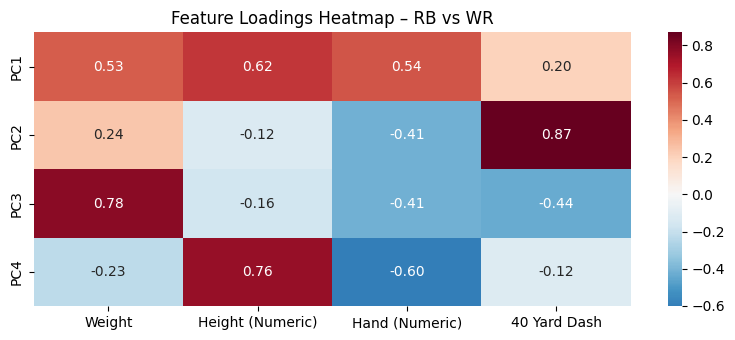

In [173]:
# PCA Figure 3: Loadings Heatmap
# Shows what each PC physically represents and which features drive it
loading_df = pd.DataFrame(
    pca_full.components_,
    index=[f'PC{i+1}' for i in range(len(features))],
    columns=features
)
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(loading_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature Loadings Heatmap – RB vs WR')
plt.tight_layout()
plt.savefig('rbwr_fig4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis:**

**Feature Loadings Heatmap**
- PC1 is a **body size axis:** Weight (0.53), Height (0.62), and Hand Size (0.54) contribute to larger players scoring higher on PC1.
- PC2 is a **speed axis:** The 40 Yard Dash dominates with a score of 0.87. This separates the fastest players from the rest regardless of size.
- Players with faster times score lower on PC2 since a smaller time is represents more speed.
- PC3 and PC4 account for the remaining variance but don't represent any meaningful athletic pattern.

In [174]:
# Final Summary
means = skill_pos_clean.groupby('Position')[features].mean()
print("FINAL SUMMARY:")
print(f"RBs: {sum(positions=='RB')} | WRs: {sum(positions=='WR')}")
print(f"PC1 ({ev[0]*100:.1f}%): Size/Frame — Weight, Height, Hand Size")
print(f"PC2 ({ev[1]*100:.1f}%): Speed — 40 Yard Dash")
print(f"2D variance retained:  {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")
print(f"RB avg weight:   {means.loc['RB','Weight']:.1f} lbs  | WR: {means.loc['WR','Weight']:.1f} lbs")
print(f"RB avg height:   {means.loc['RB','Height (Numeric)']:.2f} ft   | WR: {means.loc['WR','Height (Numeric)']:.2f} ft")
print(f"RB avg hand:     {means.loc['RB','Hand (Numeric)']:.2f} in   | WR: {means.loc['WR','Hand (Numeric)']:.2f} in")
print(f"RB avg 40 yard:  {means.loc['RB','40 Yard Dash']:.2f} sec  | WR: {means.loc['WR','40 Yard Dash']:.2f} sec")


FINAL SUMMARY:
RBs: 24 | WRs: 39
PC1 (41.4%): Size/Frame — Weight, Height, Hand Size
PC2 (26.0%): Speed — 40 Yard Dash
2D variance retained:  67.4%
RB avg weight:   208.6 lbs  | WR: 196.1 lbs
RB avg height:   5.87 ft   | WR: 6.09 ft
RB avg hand:     9.13 in   | WR: 9.29 in
RB avg 40 yard:  4.48 sec  | WR: 4.46 sec


**Concluding Statement:**

The PCA tells us that the specific 4 NFL combine measurements we looked at can be collapsed into 2 primary athletic dimensions: SIZE and SPEED. Of course there are other factors that make a good RB and WR such as route running ability, catching ability, etc. but for the purpose of this analysis, these are the two major factors that help determine a players athletic ability for these skill positions.